In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import torch
import torch.nn as nn
import torch.utils.data as data

In [2]:
df = yf.download('BTC-USD', start='2015-01-01', end='2025-11-5').reset_index()

/tmp/ipython-input-2506321159.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2015-01-01', end='2025-11-5').reset_index()
[*********************100%***********************]  1 of 1 completed


In [3]:
display(df[-2:])

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
3959,2025-11-03,106547.523438,110764.914062,105336.359375,110646.906250,72852006359
3960,2025-11-04,101590.523438,107264.882812,98962.062500,106541.421875,110967184773


будем предсказывать цену закрытия на основании цены открытия в каждый день

Scikit-learn решает эту задачу \textbf{аналитически} (не через итерации, как в нейросетях), по формуле:

$
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$

где:

- X - матрица признаков (Open)

- y - метки (Close)

То есть он просто находит точное решение уравнения для прямой (или гиперплоскости), которая лучше всего ``приближается'' к данным.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [5]:
df.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

создаем скользящее окно в 30 дней

In [6]:
count = 0
num = 30
target = df.loc[num, 'Close']
df['target'] = None # empty column

for i in range(len(df) - 30):
  df.loc[i, 'target'] = target.values

  count += 1
  if count == 30:
    count = 0
    num += 30

    if num > len(df):
      num = len(df) - 1

    target = df.loc[num, 'Close']
df.dropna(inplace=True)

In [7]:
X = df[['Open', 'Volume', 'Close', 'Date']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [8]:
learn_col = ['Open', 'Volume', 'Close']

model = LinearRegression()
model.fit(X_train[learn_col], y_train)

y_pred = model.predict(X_test[learn_col])

In [9]:
rmse = root_mean_squared_error(y_pred, X_test['Close'])
r2 = r2_score(X_test['Close'].values, y_pred)

In [10]:
print(f'root mean square error: {rmse:.2f}')
print(f'r2 score: {r2:.2f}')

root mean square error: 3229.67
r2 score: 0.99


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
df_with_predict = pd.DataFrame({
    'date': X_test['Date'],
    'real': pd.to_numeric(X_test['Close'].values.squeeze()),
    'predict': pd.to_numeric(y_pred.squeeze())
})

In [13]:
fig = px.line(data_frame=df_with_predict, x='date',
              y=['real', 'predict'], markers=False,
              title='predict BTC with Linear Regression')
fig.show()

In [27]:
pd.to_numeric(X_test['Close'].values.squeeze())[:10]

array([25812.41601562, 25779.98242188, 25753.23632812, 26240.1953125 ,
       25905.65429688, 25895.67773438, 25832.2265625 , 25162.65429688,
       25833.34375   , 26228.32421875])

фактически у меня модель просто с определенной задержкой выдает ту же цену, что была немного ранее

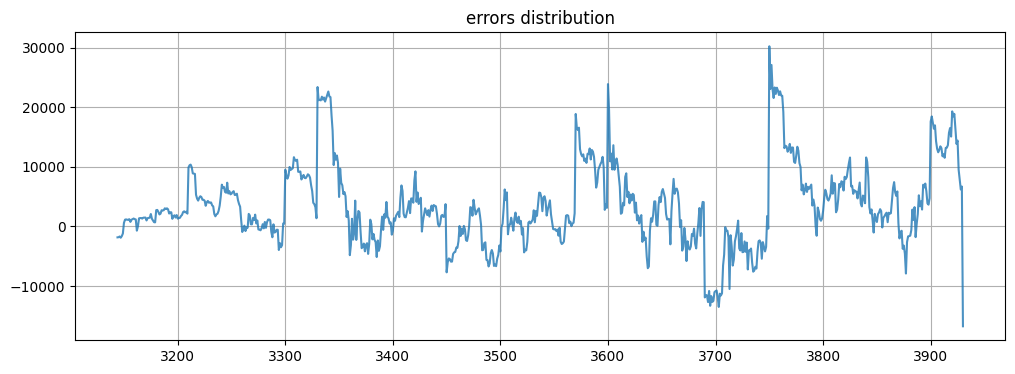

Statistics:
mean error: 3418.00
Std errors: 6686.52
Max error: 30229.15
Min error: 14.39
predict within the limits of 1%: 8.89%


In [14]:
errors = y_test.values - y_pred.squeeze()
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, errors, alpha=0.8)
plt.grid(True)
plt.title('errors distribution')

plt.show()

print("Statistics:")
print(f"mean error: {errors.mean():.2f}")
print(f"Std errors: {errors.std():.2f}")
print(f"Max error: {errors.max():.2f}")
print(f"Min error: {abs(errors).min():.2f}")

within_1_percent = np.abs(errors / y_test.values) < 0.01
print(f"predict within the limits of 1%: {within_1_percent.mean():.2%}")

Задача: с помощью глубокого обучения убрать эффект того, что модель подстраивается под данные, сделав ее прогнозы более точными, учитывающими тренды

In [15]:
df = yf.download('BTC-USD', start='2015-01-01', end='2025-11-5').reset_index()
df['target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[['Open', 'Close', 'Date']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

/tmp/ipython-input-3473845855.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [16]:
from sklearn.linear_model import Ridge

model = Ridge()
model.fit(X_train['Open'], y_train)
pred = model.predict(X_test['Open'])

rsme = root_mean_squared_error(pred, y_test)

In [17]:
df_with_predict = pd.DataFrame({
    'date': X_test['Date'],
    'real': pd.to_numeric(y_test.values.squeeze()),
    'predict': pd.to_numeric(pred.squeeze())
})

In [18]:
fig = px.line(data_frame=df_with_predict, x='date',
              y=['real', 'predict'], markers=False,
              title='predict BTC with Linear Regression')
fig.show()

In [19]:
df_btc = yf.download('BTC-USD', start='2015-01-01', end='2025-11-5').reset_index()
df_btc['target'] = None

/tmp/ipython-input-4025633620.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [20]:
df.head()

Price,Date,Close,High,Low,Open,Volume,target
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,315.032013
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,281.082001
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,264.195007
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,274.473999
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,286.188995


проблема: модель не прогнозирует цену, а выдает в качестве предсказания цену закрытия/открытия с прошлого дня, что позволяет уменьшить ошибку, но это не то, что нужно, поскольку такая торговая стратегия не приведет ни к чему, кроме потери денег

но на самом деле проблема в том, что, даже глубокие нейронные сети будут придавать силдьное значение весу последнего дня для прогнозирования текущей цены закрытия, что так же покажет нам аналогичный график.

Поэтому нужно найти другую задачу в теме прогнозирования цен на криптовалюту, к которой целесообразно применять глубокое обучение

In [31]:
df_with_predict.to_csv('linear_reg_pred.csv')